# Protocol 1 — CPP signature: physicochemical differences between two protein sets

**The key AAanalysis protocol.** Given two labelled sets of protein sequences (e.g. substrates vs. non-substrates, binders vs. non-binders, toxic vs. non-toxic), *Comparative Physicochemical Profiling* (CPP) identifies the set of position-resolved physicochemical features that most distinctly separate them — a **determinant-discovery** task that needs no black-box model. We call this feature set the **signature** of the test group.

This protocol is part of the [Protocols catalog (#35)](https://github.com/breimanntools/aaanalysis/issues/35). It follows the standard pipeline-chained structure: *When to use it -> Input -> Run -> Output -> How to interpret -> Common mistakes -> Next step.*

## When to use it

Use this protocol when you have **two labelled sets of sequences** and want to answer: *"Which physicochemical patterns distinguish my groups, and where in the sequence do they act?"* — without first committing to a black-box model. In glossary terms this is **determinant discovery**: contrast a **test** group (`label=1`) against a **reference** group (`label=0`) and read out *what physicochemically distinguishes them*.

Typical questions: substrate vs. non-substrate, cleaved vs. not cleaved, aggregation-prone vs. soluble, toxic vs. non-toxic.

Here we work at the **domain level** (dataset prefix `DOM_`): the unit of comparison is the transmembrane-domain (TMD) part set — native ground for CPP.

## Input

A `df_seq` with one row per protein and a binary `label` column (test class = 1 vs. reference class = 0). For a **domain-level** task it also carries `tmd_start` / `tmd_stop` (1-based, start- and stop-**inclusive**), from which CPP derives the **TMD-centric parts** `jmd_n` / `tmd` / `jmd_c`.

Here we use the bundled `DOM_GSEC` gamma-secretase dataset. The bridge from sequences to CPP is `SequenceFeature.get_df_parts`, which turns `df_seq` into the `df_parts` that `CPP` consumes.

For a residue/window task you would construct windows first (see the *Sampling* protocol); for embeddings/structure see the *Engineer features* protocol (`CPP.run_num`).

In [1]:
import aaanalysis as aa

aa.options["verbose"] = False
aa.options["random_state"] = 42

# Two labelled sets of sequences (label: 1 = substrate/test, 0 = reference)
df_seq = aa.load_dataset(name="DOM_GSEC", n=50)
labels = df_seq["label"].to_list()
df_seq.head()

,entry,sequence,label,tmd_start,tmd_stop,jmd_n,tmd,jmd_c
0,Q14802,MQKVTLGLLVFLAGFPVLDANDLEDKNSPFYYDWHSLQVGGLICAG...,0,37,59,NSPFYYDWHS,LQVGGLICAGVLCAMGIIIVMSA,KCKCKFGQKS
1,Q86UE4,MAARSWQDELAQQAEEGSARLREMLSVGLGFLRTELGLDLGLEPKR...,0,50,72,LGLEPKRYPG,WVILVGTGALGLLLLFLLGYGWA,AACAGARKKR
2,Q969W9,MHRLMGVNSTAAAAAGQPNVSCTCNCKRSLFQSMEITELEFVQIII...,0,41,63,FQSMEITELE,FVQIIIIVVVMMVMVVVITCLLS,HYKLSARSFI
3,P53801,MAPGVARGPTPYWRLRLGGAALLLLLIPVAAAQEPPGAACSQNTNK...,0,97,119,RWGVCWVNFE,ALIITMSVVGGTLLLGIAICCCC,CCRRKRSRKP
4,Q8IUW5,MAPRALPGSAVLAAAVFVGGAVSSPLVAPDNGSSRTLHSRTETTPS...,0,59,81,NDTGNGHPEY,IAYALVPVFFIMGLFGVLICHLL,KKKGYRCTTE


## Run

The **real** minimal path (not a one-liner): build sequence *parts* with `SequenceFeature`, construct `CPP` on those parts and call `run` with the labels, then rank the resulting signature by importance with a `TreeModel`. `CPP()` takes `df_parts` - it does **not** take `df_seq`/`labels` directly.

In [2]:
# 1) Split each sequence into parts (TMD / JMD-N / JMD-C by default)
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)

# 2) Run CPP on the parts to obtain the most discriminant features
#    (n_jobs=1 keeps it serial; multiprocessing spawn is fragile on
#    Python 3.14 + macOS without a __main__ guard)
cpp = aa.CPP(df_parts=df_parts)
df_feat = cpp.run(labels=labels, n_filter=50, n_jobs=1)
df_feat.head(8)

,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions
0,"TMD_C_JMD_C-Segment(2,3)-QIAN880106",Conformation,α-helix,α-helix (middle),Weights for alpha-helix at the window position...,0.387,0.121,0.121,0.069,0.085,2.622902e-11,7.608252e-07,"27,28,29,30,31,32,33"
1,"TMD_C_JMD_C-Segment(5,7)-FAUJ880104",Shape,Side chain length,Steric parameter,STERIMOL length of the side chain (Fauchere et...,0.382,0.264,0.264,0.156,0.156,4.591977e-11,6.659974e-07,"32,33,34"
2,"TMD_C_JMD_C-Pattern(N,1,5,8,12)-ROBB760109",Conformation,β-turn (N-term),β-turn (1st residue),Information measure for N-terminal turn (Robso...,0.377,0.127,-0.127,0.062,0.088,8.170628e-11,7.900180e-07,"21,25,28,32"
3,"TMD_C_JMD_C-Segment(4,5)-ZIMJ680104",Energy,Isoelectric point,Isoelectric point,"Isoelectric point (Zimmerman et al., 1968)",0.373,0.220,0.220,0.124,0.137,1.288802e-10,5.340613e-07,"33,34,35,36"
4,"TMD_C_JMD_C-Segment(5,7)-ONEK900101",Others,Unclassified (Others),ΔG values in peptides,Delta G values for the peptides extrapolated t...,0.373,0.115,0.115,0.066,0.113,1.288802e-10,6.230715e-07,"32,33,34"
5,"TMD_C_JMD_C-Segment(4,5)-WOLS870103",Others,PC 4,Principal Component 3 (Wold),"Principal property value z3 (Wold et al., 1987)",0.370,0.218,-0.218,0.123,0.169,1.768219e-10,5.698969e-07,"33,34,35,36"
6,"TMD_C_JMD_C-Segment(2,3)-WOLS870103",Others,PC 4,Principal Component 3 (Wold),"Principal property value z3 (Wold et al., 1987)",0.365,0.154,-0.154,0.096,0.123,3.233183e-10,5.516762e-07,"27,28,29,30,31,32,33"
7,"TMD_C_JMD_C-Segment(4,5)-FINA910103",Conformation,α-helix (C-cap),"α-helix (C-terminal, inside)","Helix termination parameter at position j-2,j-...",0.362,0.264,0.264,0.157,0.175,4.310343e-10,5.436093e-07,"33,34,35,36"


In [3]:
# 3) Rank the signature by importance: fit a tree on the CPP feature
#    matrix, then add the Monte-Carlo feature importance (percent) as
#    a new column. This is a group-level, unsigned ranking signal.
X = sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts)
tm = aa.TreeModel()
tm = tm.fit(X, labels=labels)
df_feat = tm.add_feat_importance(df_feat=df_feat)
df_feat[["feature", "category", "subcategory", "mean_dif", "abs_auc", "feat_importance"]].head(8)

,feature,category,subcategory,mean_dif,abs_auc,feat_importance
0,"TMD_C_JMD_C-Segment(2,3)-QIAN880106",Conformation,α-helix,0.121,0.387,4.527
1,"TMD_C_JMD_C-Segment(5,7)-FAUJ880104",Shape,Side chain length,0.264,0.382,4.462
2,"TMD_C_JMD_C-Pattern(N,1,5,8,12)-ROBB760109",Conformation,β-turn (N-term),-0.127,0.377,5.282
3,"TMD_C_JMD_C-Segment(4,5)-ZIMJ680104",Energy,Isoelectric point,0.220,0.373,3.031
4,"TMD_C_JMD_C-Segment(5,7)-ONEK900101",Others,Unclassified (Others),0.115,0.373,1.911
5,"TMD_C_JMD_C-Segment(4,5)-WOLS870103",Others,PC 4,-0.218,0.370,1.865
6,"TMD_C_JMD_C-Segment(2,3)-WOLS870103",Others,PC 4,-0.154,0.365,2.154
7,"TMD_C_JMD_C-Segment(4,5)-FINA910103",Conformation,α-helix (C-cap),0.264,0.362,2.285


## Output

`df_feat` is the **signature**: one row per selected feature. Each feature is one `Part-Split-Scale` combination — *where* in the sequence (part), *how* the positions are selected (split), and *which* physicochemical property is averaged (scale). Key columns:

- `feature` - the `Part-Split-Scale` identifier.
- `category` / `subcategory` - the AAontology property group.
- `mean_dif` - mean difference (test - reference); the **sign** gives the direction.
- `abs_auc` - effect size / separation strength of the feature.
- `feat_importance` - tree-based importance (percent), used to rank the signature.

Visualise the whole signature as a feature map:

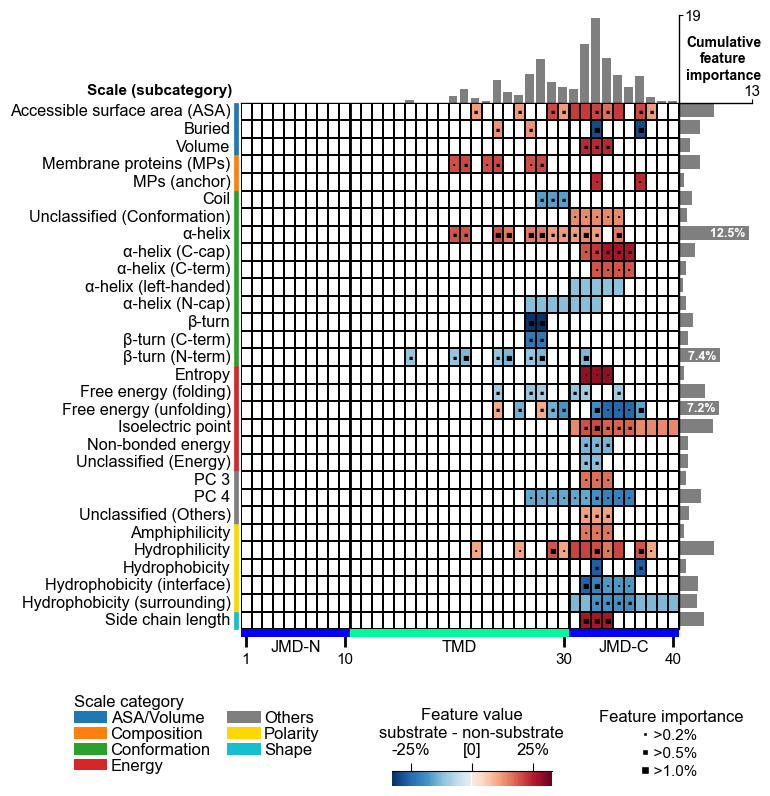

In [4]:
import matplotlib.pyplot as plt

cpp_plot = aa.CPPPlot()                 # feature_map is an INSTANCE method
aa.plot_settings(font_scale=0.65, weight_bold=False)
cpp_plot.feature_map(df_feat=df_feat, name_test="substrate", name_ref="non-substrate")
plt.show()

## How to interpret

| Output | Non-expert reading |
| --- | --- |
| high `abs_auc` | strong group-separating property |
| positive `mean_dif` | property is **higher** in the test class in that region |
| negative `mean_dif` | property is **higher** in the reference class |
| a positional feature (e.g. `Segment(2,3)` / `Pattern(...)`) | the signal depends on *where* in the part it occurs |
| a whole-part `Segment(1,1)` feature | a **compositional** (position-agnostic) difference |
| a subcategory dominating the map | that property family drives the separation |

Read the feature map as: *rows = physicochemical properties (scale subcategories), columns = positions along the parts, colour = direction & strength of the difference, top bars = cumulative feature importance.* A robust signature shows coherent blocks, not scattered single cells.

Because every scale belongs to an **AAontology** category/subcategory, the signature reads as biology: a coherent block of high-`abs_auc` features from one subcategory localised to a given part (e.g. the `tmd`) says *that* property family, *there*, is what physicochemically distinguishes the test group from the reference.

## Common mistakes

- **Calling `CPP(df_seq=...)` or `CPP().run(df_seq, labels)`** - `CPP` takes `df_parts`; build them with `SequenceFeature.get_df_parts` first.
- **Treating `CPPPlot.feature_map` as static** - it is an *instance* method (`aa.CPPPlot().feature_map(...)`), and it needs a `feat_importance` column (add it with `TreeModel.add_feat_importance`).
- **Over-reading a single feature** - interpret the *signature* (blocks of related features), and check stability before drawing biological conclusions (see the *Validate* protocol).
- **Using `len(df_seq)` for class sizes** - use the `label` column; `load_dataset(..., n=N)` returns `2N` rows (N per class).

## Next step

- **Choose your level** - is this a residue, domain, or protein task? See *Protocol 2 - Prediction tasks / levels*.
- **Explain a prediction** - turn the signature into per-sample, single-residue explanations: see *Protocol 3 - Interpretability* (`ShapModel`, sample-level `feature_map`).
- **Trust the result** - repeated-CV, bootstrap CIs and shuffled-label controls: see *Protocol 4 - Validate / Can I trust this?*
- **Reduce redundancy** - see [feature selection & redundancy reduction (#90)](https://github.com/breimanntools/aaanalysis/issues/90).